# Order Reviews Profiling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
print('Rows, Cols:', df.shape)
df.dtypes

Rows, Cols: (99224, 7)


review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str
dtype: object

In [2]:
df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


In [3]:
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
pd.DataFrame({'Count': missing, 'Pct': missing_pct}).sort_values(by='Count', ascending=False)

,Count,Pct
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532
review_id,0,0.000000
review_score,0,0.000000
order_id,0,0.000000
review_creation_date,0,0.000000
review_answer_timestamp,0,0.000000


In [4]:
print('Full row duplicates:', df.duplicated().sum())

Full row duplicates: 0


In [5]:
print('review_id duplicates:', df['review_id'].duplicated().sum())

review_id duplicates: 814


<Axes: title={'center': 'Review Score Distribution'}, xlabel='review_score'>

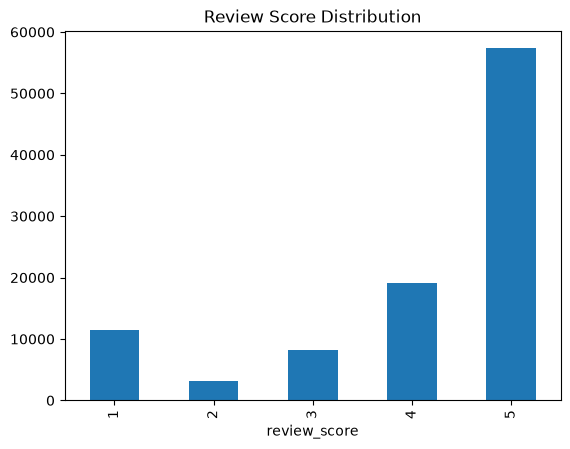

In [6]:
df['review_score'].value_counts().sort_index().plot(kind='bar', title='Review Score Distribution')

In [7]:
print('Missing review messages %:', df['review_comment_message'].isnull().mean() * 100)

Missing review messages %: 58.70253164556962


In [8]:
reviews_per_order = df.groupby('order_id').size()
print('Orders with >1 review:', (reviews_per_order > 1).sum())

Orders with >1 review: 547


### Takeaways
- Over half (58%) of the reviews do not contain a text comment.
- 5-star reviews are the most common, but there's a significant chunk of 1-star reviews as well.
- 547 orders have more than one review, which we will need to aggregate during the final join.